# Reinforcement Learning: Multi-Environment Agent Comparison

**Machine Learning — MSc Supply Chain Digitalisation**

---

## Project Overview

This project builds a reinforcement learning system from scratch that learns to play games through trial and error. Instead of learning from a static dataset, the agent interacts with a self-defined environment, receiving rewards and penalties that shape its behaviour over time.

### Research Questions
1. How do different RL algorithms (Q-Learning, SARSA, DQN) compare in terms of convergence speed and final performance?
2. How does environment complexity (maze → grid → feudal warfare) affect learning?
3. How does reward design (reward shaping) influence agent behaviour?

### Environments
| Environment | Complexity | State Space |
|-------------|-----------|-------------|
| **Maze** | Low | 36 states (6×6 grid) |
| **Grid Navigation** | Medium | 64 states (8×8 grid, random obstacles) |
| **Feudal Warfare** | High | 25 states (territory × resource bins) |

### Algorithms
| Algorithm | Type | Key Characteristic |
|-----------|------|-------------------|
| **Q-Learning** | Off-policy TD | Updates toward best possible next action |
| **SARSA** | On-policy TD | Updates toward the action actually taken |
| **DQN** | Off-policy + Neural Net | Q-function approximated by a neural network |

---

## 1. Setup

In [3]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

# Make sure we can import project modules
PROJECT_DIR = os.path.dirname(os.path.abspath('.'))
sys.path.insert(0, '.')

import config
from environments.maze_env import MazeEnv
from environments.grid_env import GridEnv
from environments.feudal_env import FeudalEnv
from agents.q_learning import QLearningAgent
from agents.sarsa import SARSAAgent
from agents.dqn import DQNAgent
from train import train as run_train, save_results

print('Libraries loaded ✓')
print(f'Training: {config.EPISODES} episodes × {config.MAX_STEPS_PER_EPISODE} max steps/episode')

Libraries loaded ✓
Training: 500 episodes × 200 max steps/episode


---

## 2. Environments

All environments share the same interface (`BaseEnv`):
- `reset()` → initial state
- `step(action)` → `(next_state, reward, done)`
- `action_space`, `state_size`

This lets any agent work with any environment without modification.

### 2.1 Maze

A 6×6 grid with fixed walls. Agent starts at top-left `(0,0)`, goal at bottom-right `(5,5)`. Must navigate around walls.

In [4]:
maze = MazeEnv()
maze.reset()
print(f'State size: {maze.state_size} | Actions: {maze.action_space} (UP/DOWN/LEFT/RIGHT)')
print('Initial maze:')
maze.render()

State size: 36 | Actions: 4 (UP/DOWN/LEFT/RIGHT)
Initial maze:

 A  . ███ .  .  . 
███ . ███ . ███ . 
 .  .  .  . ███ . 
 . ██████ .  .  . 
 .  .  . ██████ . 
███ .  .  .  .  G 



**Reward structure:**
- Goal reached: `+100`
- Each step: `-1` (encourages shorter paths)
- Hit wall: `-5`

### 2.2 Grid Navigation

An 8×8 open grid with randomly placed obstacles (~15% density). Goal position also randomizes each episode — the agent must generalize.

In [5]:
grid = GridEnv()
grid.reset()
print(f'State size: {grid.state_size} | Actions: {grid.action_space}')
print('Example grid (A=agent, G=goal, █=obstacle):')
grid.render()

State size: 64 | Actions: 4
Example grid (A=agent, G=goal, █=obstacle):

 A  .  .  . ███ .  .  . 
 .  .  .  .  .  .  G  . 
 .  .  .  .  .  .  .  . 
 . ███ .  . ███ . ███ . 
 .  .  .  .  . ███ . ███
 .  .  .  .  . ███ .  . 
 .  .  .  .  . ███ .  . 
 .  . ███ .  .  .  .  . 



**Reward structure:**
- Goal: `+100`
- Step: `-1`
- Obstacle: `-10`
- Out of bounds: `-5`

### 2.3 Feudal Warfare

A simplified territory-control strategy game. The agent commands units against a rule-based enemy, choosing whether to attack, fortify, recruit, or raid each turn.

In [6]:
feudal = FeudalEnv()
feudal.reset()
print(f'State size: {feudal.state_size} | Actions: {feudal.action_space}')
print('Actions: 0=ATTACK, 1=FORTIFY, 2=RECRUIT, 3=RAID')
print('\nSimulating 5 steps with random actions:')
for i in range(5):
    action = np.random.randint(feudal.action_space)
    action_names = ['ATTACK', 'FORTIFY', 'RECRUIT', 'RAID']
    state, reward, done = feudal.step(action)
    feudal.render()
    print(f'  Action: {action_names[action]} | Reward: {reward:+.0f} | Done: {done}')
    if done:
        break

State size: 25 | Actions: 4
Actions: 0=ATTACK, 1=FORTIFY, 2=RECRUIT, 3=RAID

Simulating 5 steps with random actions:
  Turn   1 | Agent: 2 terr | Enemy: 2 terr | Resources: 2 | [██░░░░▒▒]
  Action: ATTACK | Reward: +1 | Done: False
  Turn   2 | Agent: 1 terr | Enemy: 3 terr | Resources: 1 | [█░░░░▒▒▒]
  Action: ATTACK | Reward: -19 | Done: False
  Turn   3 | Agent: 1 terr | Enemy: 3 terr | Resources: 3 | [█░░░░▒▒▒]
  Action: RECRUIT | Reward: +1 | Done: False
  Turn   4 | Agent: 1 terr | Enemy: 3 terr | Resources: 3 | [█░░░░▒▒▒]
  Action: RAID | Reward: -2 | Done: False
  Turn   5 | Agent: 1 terr | Enemy: 3 terr | Resources: 5 | [█░░░░▒▒▒]
  Action: RECRUIT | Reward: +1 | Done: False


**Reward structure:**
- Capture territory: `+20` | Lose territory: `-20`
- Win all territories: `+100` | Lose all: `-100`
- Survive a turn: `+1`

---

## 3. Algorithms

### 3.1 Q-Learning (Off-policy TD)

Stores a Q-table: `Q[state][action]` = expected future reward.

**Update rule:**
$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

Key: updates toward the **best possible** next action — not what was actually taken.

### 3.2 SARSA (On-policy TD)

Same structure but uses the **actually taken** next action:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s',a') - Q(s,a) \right]$$

Effect: SARSA is more **conservative** — it accounts for the agent's own exploration behaviour during updates.

### 3.3 DQN (Deep Q-Network)

Replaces the Q-table with a neural network:
```
Input (one-hot state) → Linear(64) → ReLU → Linear(64) → ReLU → Linear(n_actions)
```

Two key tricks for stability:
1. **Experience replay** — random minibatches from a buffer break temporal correlations
2. **Target network** — separate frozen network for TD targets, synced every 100 steps

In [7]:
# Inspect the DQN architecture
import torch
dqn_agent = DQNAgent(state_size=36, action_size=4)
print('DQN Online Network:')
print(dqn_agent.online_net)
total_params = sum(p.numel() for p in dqn_agent.online_net.parameters())
print(f'\nTotal parameters: {total_params}')

DQN Online Network:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=36, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 6788


---

## 4. Training

Train all 9 combinations (3 environments × 3 agents). Results saved to `results/` as CSVs.

⚠️ **This cell runs all training — takes ~2–5 minutes. Skip and load pre-saved results if already run.**

In [8]:
ENVS   = ['maze', 'grid', 'feudal']
AGENTS = ['qlearning', 'sarsa', 'dqn']

os.makedirs('results', exist_ok=True)

all_results = {}
for env_name in ENVS:
    for agent_name in AGENTS:
        print(f'Training: {env_name} × {agent_name}...')
        rewards = run_train(env_name, agent_name, verbose=False)
        save_results(env_name, agent_name, rewards)
        all_results[(env_name, agent_name)] = rewards

print('\nTraining complete!')

Training: maze × qlearning...
  Saved → results/maze_qlearning_rewards.csv
Training: maze × sarsa...
  Saved → results/maze_sarsa_rewards.csv
Training: maze × dqn...
  Saved → results/maze_dqn_rewards.csv
Training: grid × qlearning...
  Saved → results/grid_qlearning_rewards.csv
Training: grid × sarsa...
  Saved → results/grid_sarsa_rewards.csv
Training: grid × dqn...
  Saved → results/grid_dqn_rewards.csv
Training: feudal × qlearning...
  Saved → results/feudal_qlearning_rewards.csv
Training: feudal × sarsa...
  Saved → results/feudal_sarsa_rewards.csv
Training: feudal × dqn...
  Saved → results/feudal_dqn_rewards.csv

Training complete!


---

## 5. Results & Analysis

### 5.1 Learning Curves

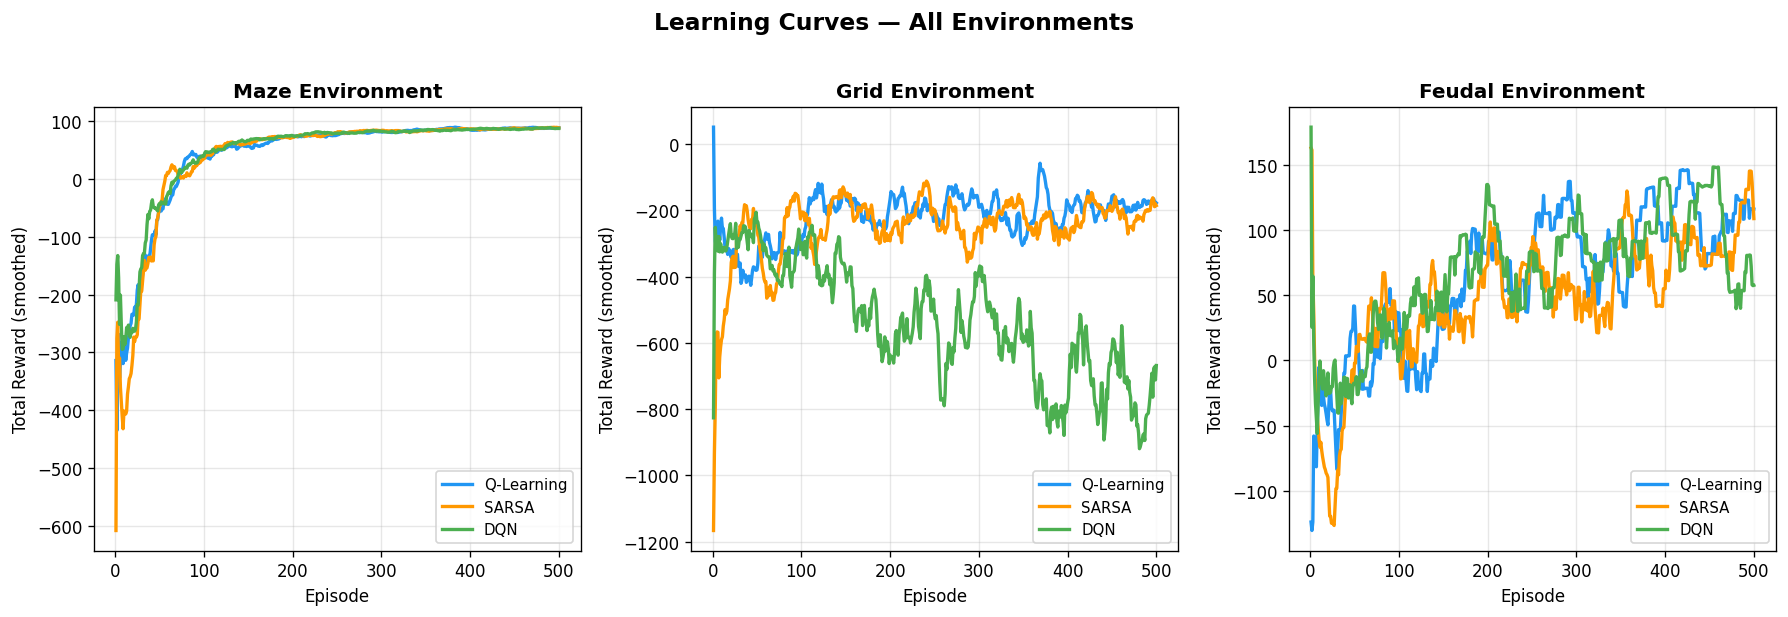

In [9]:
COLORS = {'qlearning': '#2196F3', 'sarsa': '#FF9800', 'dqn': '#4CAF50'}
LABELS = {'qlearning': 'Q-Learning', 'sarsa': 'SARSA', 'dqn': 'DQN'}
WINDOW = 20

def smooth(values, w=WINDOW):
    return pd.Series(values).rolling(w, min_periods=1).mean().values

def load_rewards(env_name, agent_name):
    path = f'results/{env_name}_{agent_name}_rewards.csv'
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)['reward'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, env_name in zip(axes, ENVS):
    for agent_name in AGENTS:
        rewards = load_rewards(env_name, agent_name)
        if rewards is None:
            continue
        episodes = range(1, len(rewards) + 1)
        ax.plot(episodes, smooth(rewards), color=COLORS[agent_name],
                label=LABELS[agent_name], linewidth=2)
    ax.set_title(f'{env_name.capitalize()} Environment', fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward (smoothed)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Learning Curves — All Environments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/figures/learning_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Final Performance Comparison

Average Reward — Last 50 Episodes:


,Q-Learning,SARSA,DQN
Maze,88.7,87.9,87.5
Grid,-185.8,-215.2,-747.6
Feudal,111.5,94.6,68.6


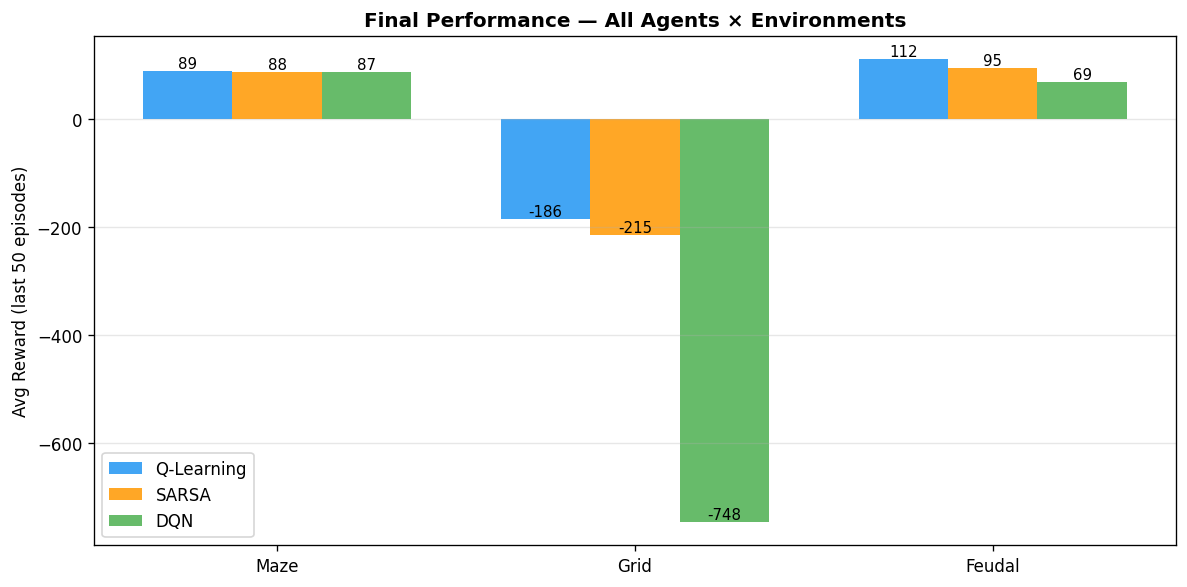

In [10]:
# Average reward over last 50 episodes for each combination
final_perf = {}
for env_name in ENVS:
    for agent_name in AGENTS:
        rewards = load_rewards(env_name, agent_name)
        if rewards is not None:
            final_perf[(env_name, agent_name)] = np.mean(rewards[-50:])

# Display as table
df_perf = pd.DataFrame(
    [[final_perf.get((env, agent), float('nan')) for agent in AGENTS] for env in ENVS],
    index=[e.capitalize() for e in ENVS],
    columns=[LABELS[a] for a in AGENTS]
).round(1)

print('Average Reward — Last 50 Episodes:')
display(df_perf)

# Bar chart
x = np.arange(len(ENVS))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, agent_name in enumerate(AGENTS):
    vals = [final_perf.get((env, agent_name), 0) for env in ENVS]
    bars = ax.bar(x + i * width, vals, width, label=LABELS[agent_name],
                  color=COLORS[agent_name], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels([e.capitalize() for e in ENVS])
ax.set_ylabel('Avg Reward (last 50 episodes)')
ax.set_title('Final Performance — All Agents × Environments', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/comparison_bar.png', dpi=150)
plt.show()

### 5.3 Policy Heatmap — Maze (Q-Learning)

After training, we can inspect the Q-table directly to see what the agent has learned: at each cell, which action does it prefer?

Training done. Final ε = 0.082


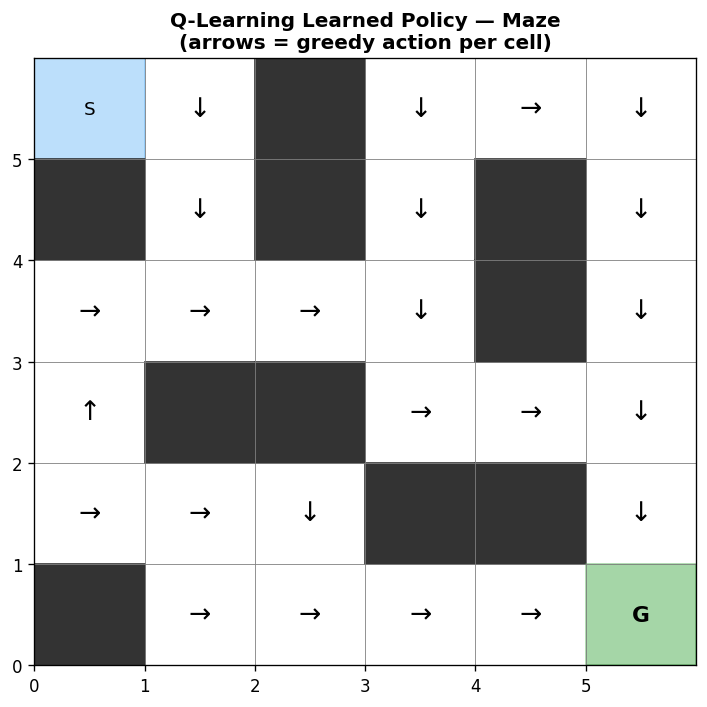

In [11]:
from environments.maze_env import DEFAULT_MAZE
from collections import defaultdict

# Train a Q-Learning agent on Maze and capture its Q-table
env = MazeEnv()
agent = QLearningAgent(env.state_size, env.action_space)

for ep in range(config.EPISODES):
    state = env.reset()
    for _ in range(config.MAX_STEPS_PER_EPISODE):
        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state
        if done:
            break
    agent.decay_epsilon()

print(f'Training done. Final ε = {agent.epsilon:.3f}')

# Draw policy heatmap
size = config.MAZE_SIZE
action_arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}
fig, ax = plt.subplots(figsize=(6, 6))

for r in range(size):
    for c in range(size):
        s = r * size + c
        if DEFAULT_MAZE[r, c] == 1:
            ax.add_patch(plt.Rectangle((c, size-1-r), 1, 1, color='#333'))
        elif (r, c) == (size-1, size-1):
            ax.add_patch(plt.Rectangle((c, size-1-r), 1, 1, color='#4CAF50', alpha=0.5))
            ax.text(c+0.5, size-1-r+0.5, 'G', ha='center', va='center', fontsize=13, fontweight='bold')
        elif (r, c) == (0, 0):
            ax.add_patch(plt.Rectangle((c, size-1-r), 1, 1, color='#2196F3', alpha=0.3))
            ax.text(c+0.5, size-1-r+0.5, 'S', ha='center', va='center', fontsize=11)
        else:
            best = int(np.argmax(agent.q_table[s]))
            ax.text(c+0.5, size-1-r+0.5, action_arrows[best],
                    ha='center', va='center', fontsize=16)

ax.set_xlim(0, size); ax.set_ylim(0, size)
ax.set_xticks(range(size)); ax.set_yticks(range(size))
ax.grid(True, color='gray', linewidth=0.5)
ax.set_title('Q-Learning Learned Policy — Maze\n(arrows = greedy action per cell)', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/maze_policy_heatmap.png', dpi=150)
plt.show()

### 5.4 Reward Shaping Experiment

How does the penalty for hitting an obstacle affect learning in the Grid environment?

We test Q-Learning with three obstacle penalty values and compare convergence speed.

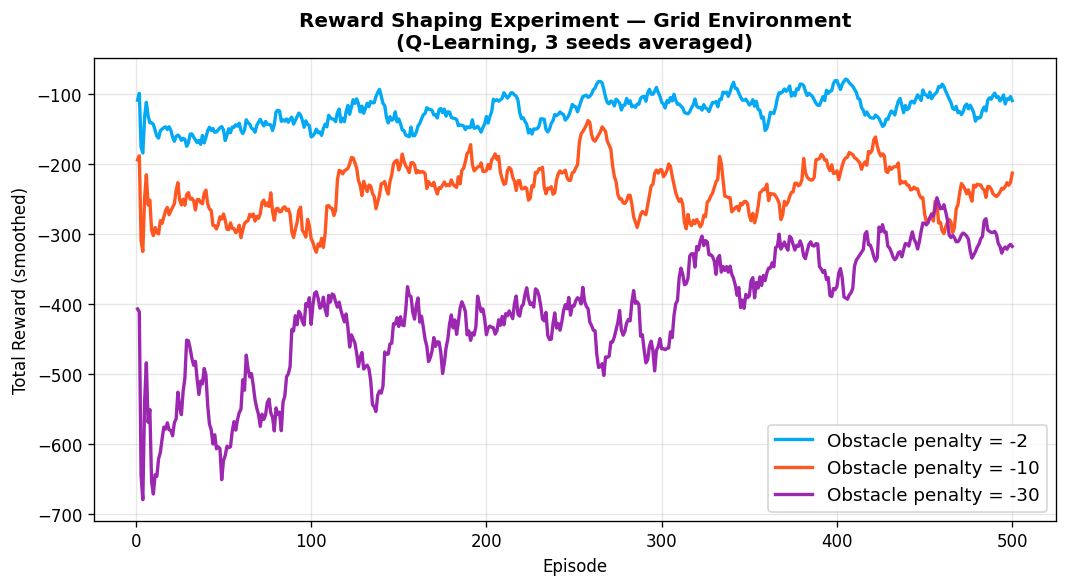

In [12]:
penalties = [-2, -10, -30]
penalty_colors = ['#03A9F4', '#FF5722', '#9C27B0']
n_seeds = 3
all_rewards = {}

for penalty in penalties:
    seed_rewards = []
    for seed in range(n_seeds):
        np.random.seed(seed)
        env = GridEnv()
        agent = QLearningAgent(env.state_size, env.action_space)
        episode_rewards = []
        for _ in range(config.EPISODES):
            state = env.reset()
            total = 0.0
            for _ in range(config.MAX_STEPS_PER_EPISODE):
                action = agent.select_action(state)
                next_state, reward, done = env.step(action)
                if reward == -10:  # obstacle hit
                    reward = penalty
                agent.update(state, action, reward, next_state, done)
                state = next_state
                total += reward
                if done:
                    break
            agent.decay_epsilon()
            episode_rewards.append(total)
        seed_rewards.append(episode_rewards)
    all_rewards[penalty] = np.mean(seed_rewards, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
for penalty, color in zip(penalties, penalty_colors):
    smoothed = smooth(all_rewards[penalty])
    ax.plot(range(1, config.EPISODES + 1), smoothed, color=color,
            label=f'Obstacle penalty = {penalty}', linewidth=2)

ax.set_title('Reward Shaping Experiment — Grid Environment\n(Q-Learning, 3 seeds averaged)', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward (smoothed)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/reward_shaping_grid.png', dpi=150)
plt.show()

---

## 6. Analysis & Discussion

### Q-Learning vs. SARSA

Q-Learning and SARSA often converge to similar final performance, but the path differs:
- **Q-Learning** updates more aggressively — assumes optimal future behaviour. Can be faster to converge in deterministic environments (Maze).
- **SARSA** is more conservative — includes the cost of its own exploration. In stochastic environments (Feudal), this leads to more stable but slower learning.

### Why DQN?

Tabular Q-Learning and SARSA store one value per `(state, action)` pair. For small environments (36 or 64 states), this is fine. But for real-world problems — a chess board has ~10⁴³ states — a table is impossible.

DQN solves this by training a neural network to *generalise* across states. The same network handles all three environments here, despite different state space sizes.

### Reward Shaping

The reward shaping experiment shows that penalty magnitude directly controls risk aversion:
- **Low penalty (-2):** Agent treats obstacles casually, explores freely, may find shortcuts
- **High penalty (-30):** Agent becomes very cautious, avoids obstacles at all costs — sometimes over-cautiously
- **Medium (-10):** Usually the best balance — exploration with sensible caution

This has direct implications for supply chain applications: setting backorder penalty too high makes an inventory agent over-stock, too low makes it under-stock.

### Connection to the Beer Game (Auto Digitalisation course)

The `Auto Beer Game` (Automation & Digitalisation assignment) is RL applied to supply chain:
- **State:** inventory levels, backorders, pipeline
- **Actions:** how many units to order
- **Reward:** minimise holding + backorder costs

The same Q-Learning loop used in the Maze here was used to learn an ordering policy that reduces the **bullwhip effect** — a real supply chain phenomenon. This project demonstrates the underlying mechanics that make that possible.

---

## 7. Conclusion

This project demonstrated three key RL algorithms across three environments of increasing complexity:

1. **All three agents learn** — reward curves improve over episodes in every environment, confirming that trial-and-error learning works without any labelled dataset.

2. **On-policy vs. off-policy matters in practice** — SARSA's conservative updates are better suited to stochastic environments; Q-Learning's aggressive updates converge faster in deterministic ones.

3. **DQN enables scaling** — neural function approximation allows the same algorithm to generalise across different state space sizes, which is the key to real-world RL applications.

4. **Reward design drives behaviour** — the penalty structure shapes what the agent values, not just whether it learns. This is a critical design decision in any applied RL system.

**Practical implication:** These same mechanisms underpin modern RL applications in supply chain (inventory optimisation, production scheduling) and beyond (autonomous vehicles, robotics, dynamic pricing).

---

## Section 5: Interactive Visualization

Watch a trained agent play in real time, or play the games yourself — all inside the notebook using interactive widgets.

> **Tip:** For a smoother keyboard experience (WASD controls), use the terminal:\
> `python play.py --env maze --mode human`

In [13]:
import ipywidgets as widgets
from IPython.display import display as ipy_display
import threading, time, sys, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 100

sys.path.insert(0, '.')
import config
from environments.maze_env import MazeEnv
from environments.grid_env import GridEnv
from environments.feudal_env import FeudalEnv
from agents.q_learning import QLearningAgent
from agents.sarsa import SARSAAgent
from agents.dqn import DQNAgent

def _build_env(name):
    if name == 'maze':   return MazeEnv(size=config.MAZE_SIZE)
    if name == 'grid':   return GridEnv(size=config.GRID_SIZE, obstacle_density=config.GRID_OBSTACLE_DENSITY)
    if name == 'feudal': return FeudalEnv(max_turns=config.FEUDAL_MAX_TURNS)

def _build_and_train(agent_name, env, episodes=300):
    if agent_name == 'qlearning': agent = QLearningAgent(env.state_size, env.action_space)
    elif agent_name == 'sarsa':   agent = SARSAAgent(env.state_size, env.action_space)
    else:                         agent = DQNAgent(env.state_size, env.action_space)
    for _ in range(episodes):
        state = env.reset()
        if agent_name == 'sarsa': act = agent.select_action(state)
        for _ in range(config.MAX_STEPS_PER_EPISODE):
            if agent_name == 'sarsa':
                ns, r, done = env.step(act); na = agent.select_action(ns)
                agent.update(state, act, r, ns, na, done); state, act = ns, na
            else:
                act = agent.select_action(state); ns, r, done = env.step(act)
                agent.update(state, act, r, ns, done); state = ns
            if done: break
        agent.decay_epsilon()
    agent.epsilon = 0.0
    return agent

print('Interactive visualization ready ✓')

Interactive visualization ready ✓


### 5A. Watch a Trained Agent Play

The agent trains quickly (300 episodes) then plays with ε=0 (fully greedy). Use the buttons to step through manually or let it run automatically.

In [14]:
class AgentAnimator:
    """Watch a trained RL agent play — colored grid + ipywidgets controls."""

    COLORS = {
        'open':  [240, 240, 240],
        'wall':  [50,  50,  50 ],
        'trail': [255, 193, 7  ],
        'goal':  [76,  175, 80 ],
        'agent': [33,  150, 243],
    }

    def __init__(self, env_name, agent_name='qlearning', train_episodes=300):
        self.env_name = env_name
        self.env = _build_env(env_name)
        print(f'Training {agent_name} on {env_name} ({train_episodes} ep)...', end=' ', flush=True)
        self.agent = _build_and_train(agent_name, self.env, train_episodes)
        print('Done ✓')
        self._state = self.env.reset()
        self._done = False
        self._step = 0
        self._total_reward = 0.0
        self._visited = set()
        self._playing = False
        self._speed_slider = None
        self._info = None
        self._fig = self._ax = self._im = None

    def _get_goal(self):
        return self.env.goal_pos if hasattr(self.env, 'goal_pos') else self.env.goal

    def _make_grid_array(self):
        size = self.env.size
        rgb = np.full((size, size, 3), self.COLORS['open'], dtype=np.uint8)
        if hasattr(self.env, 'maze'):
            for r in range(size):
                for c in range(size):
                    if self.env.maze[r, c] == 1:
                        rgb[r, c] = self.COLORS['wall']
        elif hasattr(self.env, 'obstacles'):
            for (r, c) in self.env.obstacles:
                rgb[r, c] = self.COLORS['wall']
        for (r, c) in self._visited:
            if list(rgb[r, c]) == self.COLORS['open']:
                rgb[r, c] = self.COLORS['trail']
        gr, gc = self._get_goal()
        rgb[gr, gc] = self.COLORS['goal']
        ar, ac = self.env.agent_pos
        rgb[ar, ac] = self.COLORS['agent']
        return rgb

    def _init_figure(self):
        if self.env_name == 'feudal':
            self._fig, self._ax = plt.subplots(figsize=(7, 2))
        else:
            self._fig, self._ax = plt.subplots(figsize=(5, 5))
            self._im = self._ax.imshow(self._make_grid_array(), interpolation='nearest')
            self._ax.set_xticks([]); self._ax.set_yticks([])
            label = 'Maze (6×6)' if self.env_name == 'maze' else 'Grid Navigation (8×8)'
            self._ax.set_title(f'{label} — Agent (blue) → Goal (green)')
        plt.tight_layout()

    def _update_figure(self):
        if self.env_name == 'feudal':
            self._ax.cla()
            a = self.env.agent_territories; e = self.env.enemy_territories
            n = FeudalEnv.TOTAL_TERRITORIES - a - e
            self._ax.barh(0, a, color='#2196F3', height=0.6, label='Agent')
            self._ax.barh(0, n, left=a, color='#9E9E9E', height=0.6, label='Neutral')
            self._ax.barh(0, e, left=a+n, color='#F44336', height=0.6, label='Enemy')
            self._ax.set_xlim(0, FeudalEnv.TOTAL_TERRITORIES)
            self._ax.set_ylim(-0.5, 0.5); self._ax.set_yticks([])
            self._ax.set_xlabel(f'Turn {self.env.turn} | Resources: {self.env.resources}')
            self._ax.set_title(f'Feudal Warfare — Agent:{a}  Neutral:{n}  Enemy:{e}')
            self._ax.legend(loc='upper right', fontsize=8)
        else:
            self._im.set_data(self._make_grid_array())
        self._fig.canvas.draw_idle()

    def _step_once(self):
        if self._done: return
        if self.env_name != 'feudal' and hasattr(self.env, 'agent_pos'):
            self._visited.add(self.env.agent_pos)
        action = self.agent.select_action(self._state)
        self._state, reward, self._done = self.env.step(action)
        self._step += 1; self._total_reward += reward
        status = '✓ Done!' if self._done else 'Running'
        self._info.value = f'Step {self._step} | Reward: {self._total_reward:+.1f} | {status}'
        self._update_figure()

    def _reset(self):
        self._playing = False; time.sleep(0.1)
        self._state = self.env.reset()
        self._done = False; self._step = 0; self._total_reward = 0.0; self._visited = set()
        self._info.value = 'Reset — ready'
        self._update_figure()

    def _on_step(self, _):  self._step_once()
    def _on_stop(self, _):  self._playing = False
    def _on_reset(self, _): self._reset()

    def _on_play(self, _):
        if self._playing: return
        self._playing = True
        def loop():
            while self._playing and not self._done:
                self._step_once()
                time.sleep(self._speed_slider.value)
            self._playing = False
        threading.Thread(target=loop, daemon=True).start()

    def display(self):
        self._init_figure()
        btn_step  = widgets.Button(description='Step',   button_style='info',    layout=widgets.Layout(width='80px'))
        btn_play  = widgets.Button(description='▶ Play', button_style='success', layout=widgets.Layout(width='90px'))
        btn_stop  = widgets.Button(description='⏹ Stop', button_style='warning', layout=widgets.Layout(width='90px'))
        btn_reset = widgets.Button(description='↺ Reset', button_style='danger', layout=widgets.Layout(width='90px'))
        self._speed_slider = widgets.FloatSlider(
            value=0.4, min=0.05, max=1.5, step=0.05,
            description='Speed (s):', layout=widgets.Layout(width='280px'))
        self._info = widgets.Label(value='Ready — press Step or ▶ Play')
        btn_step.on_click(self._on_step); btn_play.on_click(self._on_play)
        btn_stop.on_click(self._on_stop); btn_reset.on_click(self._on_reset)
        out = widgets.Output()
        with out: plt.show()
        ipy_display(widgets.VBox([
            widgets.HBox([btn_step, btn_play, btn_stop, btn_reset, self._speed_slider]),
            self._info, out
        ]))

In [15]:
# Change env_name to 'grid' or 'feudal' — change agent_name to 'sarsa' or 'dqn'
animator = AgentAnimator('maze', agent_name='qlearning', train_episodes=300)
animator.display()

Training qlearning on maze (300 ep)... Done ✓


### 5B. Play Yourself

Use the on-screen buttons to navigate. Try to beat the trained agent's score!

- **Maze / Grid:** D-pad arrow buttons
- **Feudal:** Action buttons (Attack, Fortify, Recruit, Raid)

In [16]:
class HumanPlayer:
    """Play RL environments yourself using ipywidgets buttons."""

    COLORS = AgentAnimator.COLORS

    def __init__(self, env_name):
        self.env_name = env_name
        self.env = _build_env(env_name)
        self._state = self.env.reset()
        self._done = False; self._step = 0; self._total_reward = 0.0; self._visited = set()
        self._info = self._fig = self._ax = self._im = None

    def _get_goal(self):
        return self.env.goal_pos if hasattr(self.env, 'goal_pos') else self.env.goal

    def _make_grid_array(self):
        size = self.env.size
        rgb = np.full((size, size, 3), self.COLORS['open'], dtype=np.uint8)
        if hasattr(self.env, 'maze'):
            for r in range(size):
                for c in range(size):
                    if self.env.maze[r, c] == 1: rgb[r, c] = self.COLORS['wall']
        elif hasattr(self.env, 'obstacles'):
            for (r, c) in self.env.obstacles: rgb[r, c] = self.COLORS['wall']
        for (r, c) in self._visited:
            if list(rgb[r, c]) == self.COLORS['open']: rgb[r, c] = self.COLORS['trail']
        gr, gc = self._get_goal(); rgb[gr, gc] = self.COLORS['goal']
        ar, ac = self.env.agent_pos; rgb[ar, ac] = self.COLORS['agent']
        return rgb

    def _update(self):
        if self.env_name != 'feudal':
            self._im.set_data(self._make_grid_array())
        else:
            self._ax.cla()
            a = self.env.agent_territories; e = self.env.enemy_territories
            n = FeudalEnv.TOTAL_TERRITORIES - a - e
            self._ax.barh(0, a, color='#2196F3', height=0.6, label='You')
            self._ax.barh(0, n, left=a, color='#9E9E9E', height=0.6, label='Neutral')
            self._ax.barh(0, e, left=a+n, color='#F44336', height=0.6, label='Enemy')
            self._ax.set_xlim(0, FeudalEnv.TOTAL_TERRITORIES)
            self._ax.set_ylim(-0.5, 0.5); self._ax.set_yticks([])
            self._ax.set_title(f'Turn {self.env.turn} | Resources: {self.env.resources} | You:{a}  Enemy:{e}')
            self._ax.legend(loc='upper right', fontsize=8)
        self._fig.canvas.draw_idle()

    def _on_action(self, action):
        def handler(_):
            if self._done: return
            if self.env_name != 'feudal' and hasattr(self.env, 'agent_pos'):
                self._visited.add(self.env.agent_pos)
            self._state, reward, self._done = self.env.step(action)
            self._step += 1; self._total_reward += reward
            if self._done and self._total_reward > 0:
                status = '🎉 You reached the goal!'
            elif self._done:
                status = 'Game over'
            else:
                status = 'Your turn'
            self._info.value = f'Step {self._step} | Reward: {self._total_reward:+.1f} | {status}'
            self._update()
        return handler

    def _on_reset(self, _):
        self._state = self.env.reset()
        self._done = False; self._step = 0; self._total_reward = 0.0; self._visited = set()
        self._info.value = 'Reset — your turn!'
        self._update()

    def display(self):
        if self.env_name == 'feudal':
            self._fig, self._ax = plt.subplots(figsize=(7, 2))
        else:
            self._fig, self._ax = plt.subplots(figsize=(5, 5))
            self._im = self._ax.imshow(self._make_grid_array(), interpolation='nearest')
            self._ax.set_xticks([]); self._ax.set_yticks([])
            self._ax.set_title('You are the blue cell — reach the green goal!')
        plt.tight_layout()

        self._info = widgets.Label(value='Your turn! Use the buttons to move.')
        btn_reset = widgets.Button(description='↺ Reset', button_style='danger', layout=widgets.Layout(width='90px'))
        btn_reset.on_click(self._on_reset)

        if self.env_name == 'feudal':
            btns = [
                widgets.Button(description='⚔ Attack',  button_style='danger',  layout=widgets.Layout(width='115px')),
                widgets.Button(description='🛡 Fortify', button_style='info',    layout=widgets.Layout(width='115px')),
                widgets.Button(description='🏹 Recruit', button_style='success', layout=widgets.Layout(width='115px')),
                widgets.Button(description='💰 Raid',    button_style='warning', layout=widgets.Layout(width='115px')),
            ]
            for i, btn in enumerate(btns): btn.on_click(self._on_action(i))
            controls = widgets.HBox(btns + [btn_reset])
        else:
            W = widgets.Layout(width='50px')
            bu = widgets.Button(description='↑', layout=W); bd = widgets.Button(description='↓', layout=W)
            bl = widgets.Button(description='←', layout=W); br = widgets.Button(description='→', layout=W)
            bu.on_click(self._on_action(0)); bd.on_click(self._on_action(1))
            bl.on_click(self._on_action(2)); br.on_click(self._on_action(3))
            dpad = widgets.VBox([widgets.HBox([bu]), widgets.HBox([bl, bd, br])])
            controls = widgets.HBox([dpad, btn_reset])

        out = widgets.Output()
        with out: plt.show()
        ipy_display(widgets.VBox([controls, self._info, out]))

In [17]:
# Change env_name to 'grid' or 'feudal'
player = HumanPlayer('maze')
player.display()